# Final Compact Ridge Model -- Presentation (Decision 99, LOCKED)

**Status: CURRENT final architecture, LOCKED.** This notebook is a
**presentation / reproducibility layer only** for the already-locked Compact
Ridge model. It surfaces existing canonical outputs -- it does not produce
any new scientific result.

This notebook does **not**:

* perform new model selection, predictor search, or estimator comparison,
* change predictors, preprocessing, hyperparameters, or CV design,
* run any new cross-validation or refit,
* read, create, or evaluate any hold-out,
* generate any new scientific decision.

Every number, table, and figure below is read directly from artifacts
already produced and verified by the canonical scripts listed in D2.

## D1 -- Frozen architecture (Decision 99)

| | |
|---|---|
| Predictors (6) | `AGE`, `nulliparity`, `S_P_CS`, `BMI_before`, `derived_hypertension_pih_pet_spectrum`, `induction_any_bin` |
| Estimator | L2 (Ridge) logistic regression |
| Selection rule | PR-AUC one-SE band -> lowest inner Brier -> smallest C |
| Endometriosis predictor | None -- the completed exploratory endometriosis analyses found no stable incremental value; that negative result is retained, not overridden |
| `gestational_age_at_delivery_days` | Not included |

## D2 -- Canonical sources (this notebook reads curated outputs of these only)

This curated submission does not include the executable source of the lock
script or the publication-outputs generator below -- only their already-
generated aggregate result artifacts, under `results/` in this package. The
canonical sources are listed for provenance; they are not present in this
submission.

| Layer | Canonical source (canonical repository only -- not included here) |
|---|---|
| Lock / validation / refit | `analysis/modeling/final_modeling/final_compact_ridge_lock.py` |
| Publication tables/figures | `analysis/reports/compact_ridge_final_outputs.py` |
| Scientific summary | `docs/finalization/COMPACT_RIDGE_FINAL_LOCK.md` (curated copy included in this submission at `documentation/COMPACT_RIDGE_FINAL_LOCK.md`) |
| Decision record | Decision 99, `docs/clinical_decisions/manual_decisions_log.md` |

**Caveat carried through every section below:** these results are internal
repeated subject-grouped cross-validation performed *after* exploratory
model development on the same dataset -- not independent or external
validation.

In [1]:
import json
from pathlib import Path

import pandas as pd

# Submission-relative root resolution: walk upward from the notebook's
# working directory until a directory containing both results/ and
# notebooks/ subdirectories is found. This package has no CLAUDE.md (that
# is a canonical-repository-only marker), so root detection uses the
# submission's own known top-level structure instead.
PROJECT_ROOT = Path.cwd()
while not ((PROJECT_ROOT / "results").is_dir() and (PROJECT_ROOT / "notebooks").is_dir()) and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORT_DIR = PROJECT_ROOT / "results" / "tables" / "reproducibility"
REFIT_DIR = REPORT_DIR
RESULTS_DIR = PROJECT_ROOT / "results" / "tables" / "compact_ridge_final"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "compact_ridge_final"

locked_validation_manifest = json.loads((REPORT_DIR / "locked_validation_manifest.json").read_text(encoding="utf-8"))
final_refit_manifest = json.loads((REFIT_DIR / "final_refit_manifest.json").read_text(encoding="utf-8"))

# Read-only integrity check against the already-locked artifacts -- no new
# computation, only confirming the frozen numbers this notebook will display.
assert locked_validation_manifest["n_folds_ok"] == 50
assert locked_validation_manifest["n_folds_total"] == 50
assert locked_validation_manifest["n_rows"] == 431
assert final_refit_manifest["n_rows_used"] == 431
assert final_refit_manifest["converged"] is True
assert tuple(final_refit_manifest["frozen_predictors"]) == (
    "AGE", "nulliparity", "S_P_CS", "BMI_before",
    "derived_hypertension_pih_pet_spectrum", "induction_any_bin",
)

print("Locked internal-validation run: "
      f"{locked_validation_manifest['n_folds_ok']}/{locked_validation_manifest['n_folds_total']} outer folds OK, "
      f"n_rows={locked_validation_manifest['n_rows']}")
print("Final full-data refit: "
      f"n_rows_used={final_refit_manifest['n_rows_used']}, "
      f"chosen_C={final_refit_manifest['chosen_C']:.4f}, "
      f"intercept={final_refit_manifest['intercept']:.4f}, "
      f"converged={final_refit_manifest['converged']}")

Locked internal-validation run: 50/50 outer folds OK, n_rows=431
Final full-data refit: n_rows_used=431, chosen_C=0.3162, intercept=-2.0476, converged=True


---
## D3 -- Locked internal-validation performance

Repeated 10x5 subject-grouped outer CV (50 outer folds, 0 failures). These
are the FINAL reported model-performance numbers -- read directly from
`results/tables/compact_ridge_final/table_final_model_performance.csv`
(itself built read-only from `locked_validation_manifest.json`).

The historical Stage 3 / LASSO row is the previously locked, now-superseded
architecture (Decision 99 superseded it) -- shown only as a contextual
historical comparator, not a current candidate model.

In [2]:
performance_table = pd.read_csv(RESULTS_DIR / "table_final_model_performance.csv")
performance_table

,metric,compact_ridge_mean,compact_ridge_sd,historical_stage3_lasso_baseline_mean,historical_stage3_lasso_baseline_sd
0,PR-AUC,0.3479,0.0146,0.2720,0.0176
1,AUROC,0.7977,0.0112,0.7150,0.0294
2,Brier score,0.1057,0.0014,0.1270,0.0139
3,Brier skill score,0.1300,0.0119,-0.0449,0.1140
4,Log-loss,0.3365,0.0054,0.4206,0.0701
5,Calibration intercept,0.1623,0.0964,-0.6890,0.6670
6,Calibration slope,1.1153,0.0657,0.6604,0.3475


### Repeat-level detail (10 outer-CV repeats)

The table above reports the mean/SD across the 10 repeats shown here in
full, straight from the locked manifest's per-repeat aggregation --
`results/tables/reproducibility/repeat_level_metrics.csv`.

In [3]:
repeat_level_metrics = pd.read_csv(REPORT_DIR / "repeat_level_metrics.csv")
repeat_level_metrics

,repeat,pr_auc,auroc,brier,brier_skill,logloss,calibration_intercept,calibration_slope
0,1,0.349265,0.808684,0.104318,0.141416,0.331828,0.288272,1.195320
1,2,0.326996,0.782322,0.107502,0.115215,0.343160,0.055822,1.043863
2,3,0.348749,0.797829,0.106196,0.125959,0.337734,0.178967,1.125721
3,4,0.355695,0.810146,0.104286,0.141676,0.330123,0.233504,1.164157
4,5,0.351916,0.790762,0.106346,0.124722,0.338991,0.085687,1.058060
5,6,0.335985,0.783850,0.107231,0.117441,0.342000,0.038850,1.035881
6,7,0.368160,0.806735,0.104092,0.143278,0.331311,0.210480,1.148579
7,8,0.362205,0.807599,0.104334,0.141284,0.332493,0.286657,1.204776
8,9,0.323660,0.785202,0.107643,0.114054,0.344347,0.055093,1.039850
9,10,0.356226,0.803589,0.105066,0.135258,0.333140,0.190132,1.136793


---
## D4 -- Full-data refit: coefficients and adjusted odds ratios

The frozen architecture is refit ONCE on all 431 deliveries (same tuning
procedure, one canonical grouped inner split). Its own training-set fit
statistics are never reported as model performance -- only Part D3's
repeated-CV numbers are. These are penalized Ridge coefficients on the
standardized/encoded modeling scale, **not** conventional adjusted odds
ratios.

`BMI_before` is flagged as directionally unstable (sign consistency 0.54
across the 50 outer validation folds, vs. 1.00 for every other
continuous/binary predictor) -- its full-refit coefficient sign should not
be over-interpreted.

In [4]:
ridge_coefficients_table = pd.read_csv(RESULTS_DIR / "table_final_ridge_coefficients.csv")
ridge_coefficients_table

,source_predictor,encoded_level,ridge_coefficient_standardized_scale,direction,outer_fold_median_coefficient,outer_fold_coefficient_iqr,outer_fold_sign_consistency,n_outer_folds,stability_flag
0,AGE,NaN,0.5414,positive,0.4790,0.0854,1.00,50.0,stable
1,nulliparity,NaN,0.8896,positive,0.7391,0.1425,1.00,50.0,stable
2,S_P_CS,NaN,0.4422,positive,0.3439,0.1386,1.00,50.0,stable
3,induction_any_bin,NaN,0.7931,positive,0.7075,0.0914,1.00,50.0,stable
4,derived_hypertension_pih_pet_spectrum,no_hypertensive_disorder,-0.3320,negative,NaN,NaN,NaN,NaN,not available (categorical level; stability tr...
5,derived_hypertension_pih_pet_spectrum,pih_gestational_htn,0.1352,positive,NaN,NaN,NaN,NaN,not available (categorical level; stability tr...
6,derived_hypertension_pih_pet_spectrum,preeclampsia_spectrum,0.1936,positive,NaN,NaN,NaN,NaN,not available (categorical level; stability tr...
7,BMI_before,NaN,-0.0282,negative,-0.0152,0.0981,0.54,50.0,UNSTABLE (directional sign flips across outer ...


### Secondary analysis: adjusted odds ratios

A separate, prespecified descriptive association analysis -- ordinary
(unpenalized) multivariable logistic regression on the same six frozen
predictors, entered together. **This is not the predictive Compact Ridge
model, not a causal model, and not a variable-selection exercise.** Source:
`results/tables/compact_ridge_final/adjusted_or/table_adjusted_odds_ratios.csv`.

In [5]:
adjusted_or_table = pd.read_csv(RESULTS_DIR / "adjusted_or" / "table_adjusted_odds_ratios.csv")
adjusted_or_table

,source_variable,clinical_label,comparison_unit,reference_level,adjusted_or,ci_lower,ci_upper,coefficient,std_error,p_value
0,AGE,Age (per 1-year increase),per 1-year increase,n/a (continuous),1.1365,1.0655,1.2122,0.1279,0.0329,0.0001
1,nulliparity,Nulliparous vs. non-nulliparous (prior birth),nulliparous (1) vs. prior birth (0),0 = non-nulliparous / prior birth,8.3675,3.3313,21.0174,2.1244,0.4699,0.0000
2,S_P_CS,Prior cesarean vs. no prior cesarean,prior cesarean (1) vs. none (0),0 = no prior cesarean,14.6165,3.2964,64.8117,2.6822,0.7599,0.0004
3,BMI_before,Pre-pregnancy BMI (per 1 kg/m² increase),per 1 kg/m² increase,n/a (continuous),0.9889,0.9289,1.0528,-0.0111,0.0320,0.7272
4,derived_hypertension_pih_pet_spectrum,PIH / gestational hypertension vs. no hyperten...,pih_gestational_htn vs. no_hypertensive_disorder,no_hypertensive_disorder,2.1507,0.3820,12.1085,0.7658,0.8817,0.3851
5,derived_hypertension_pih_pet_spectrum,Preeclampsia spectrum vs. no hypertensive diso...,preeclampsia_spectrum vs. no_hypertensive_diso...,no_hypertensive_disorder,2.2476,0.5568,9.0725,0.8099,0.7119,0.2553
6,induction_any_bin,Labor induction vs. no induction,induction (1) vs. none (0),0 = no induction,6.0060,2.8726,12.5571,1.7928,0.3763,0.0000


---
## D5 -- Calibration, discrimination, and coefficient stability

The three figures below are already-generated read-only artifacts,
originally produced by `analysis/reports/compact_ridge_final_outputs.py`
in the canonical repository (not included in this submission) and included
here as curated files at `results/figures/compact_ridge_final/`, aggregated
exactly per `figures_metadata.md` in that directory. They are displayed
here, not regenerated.

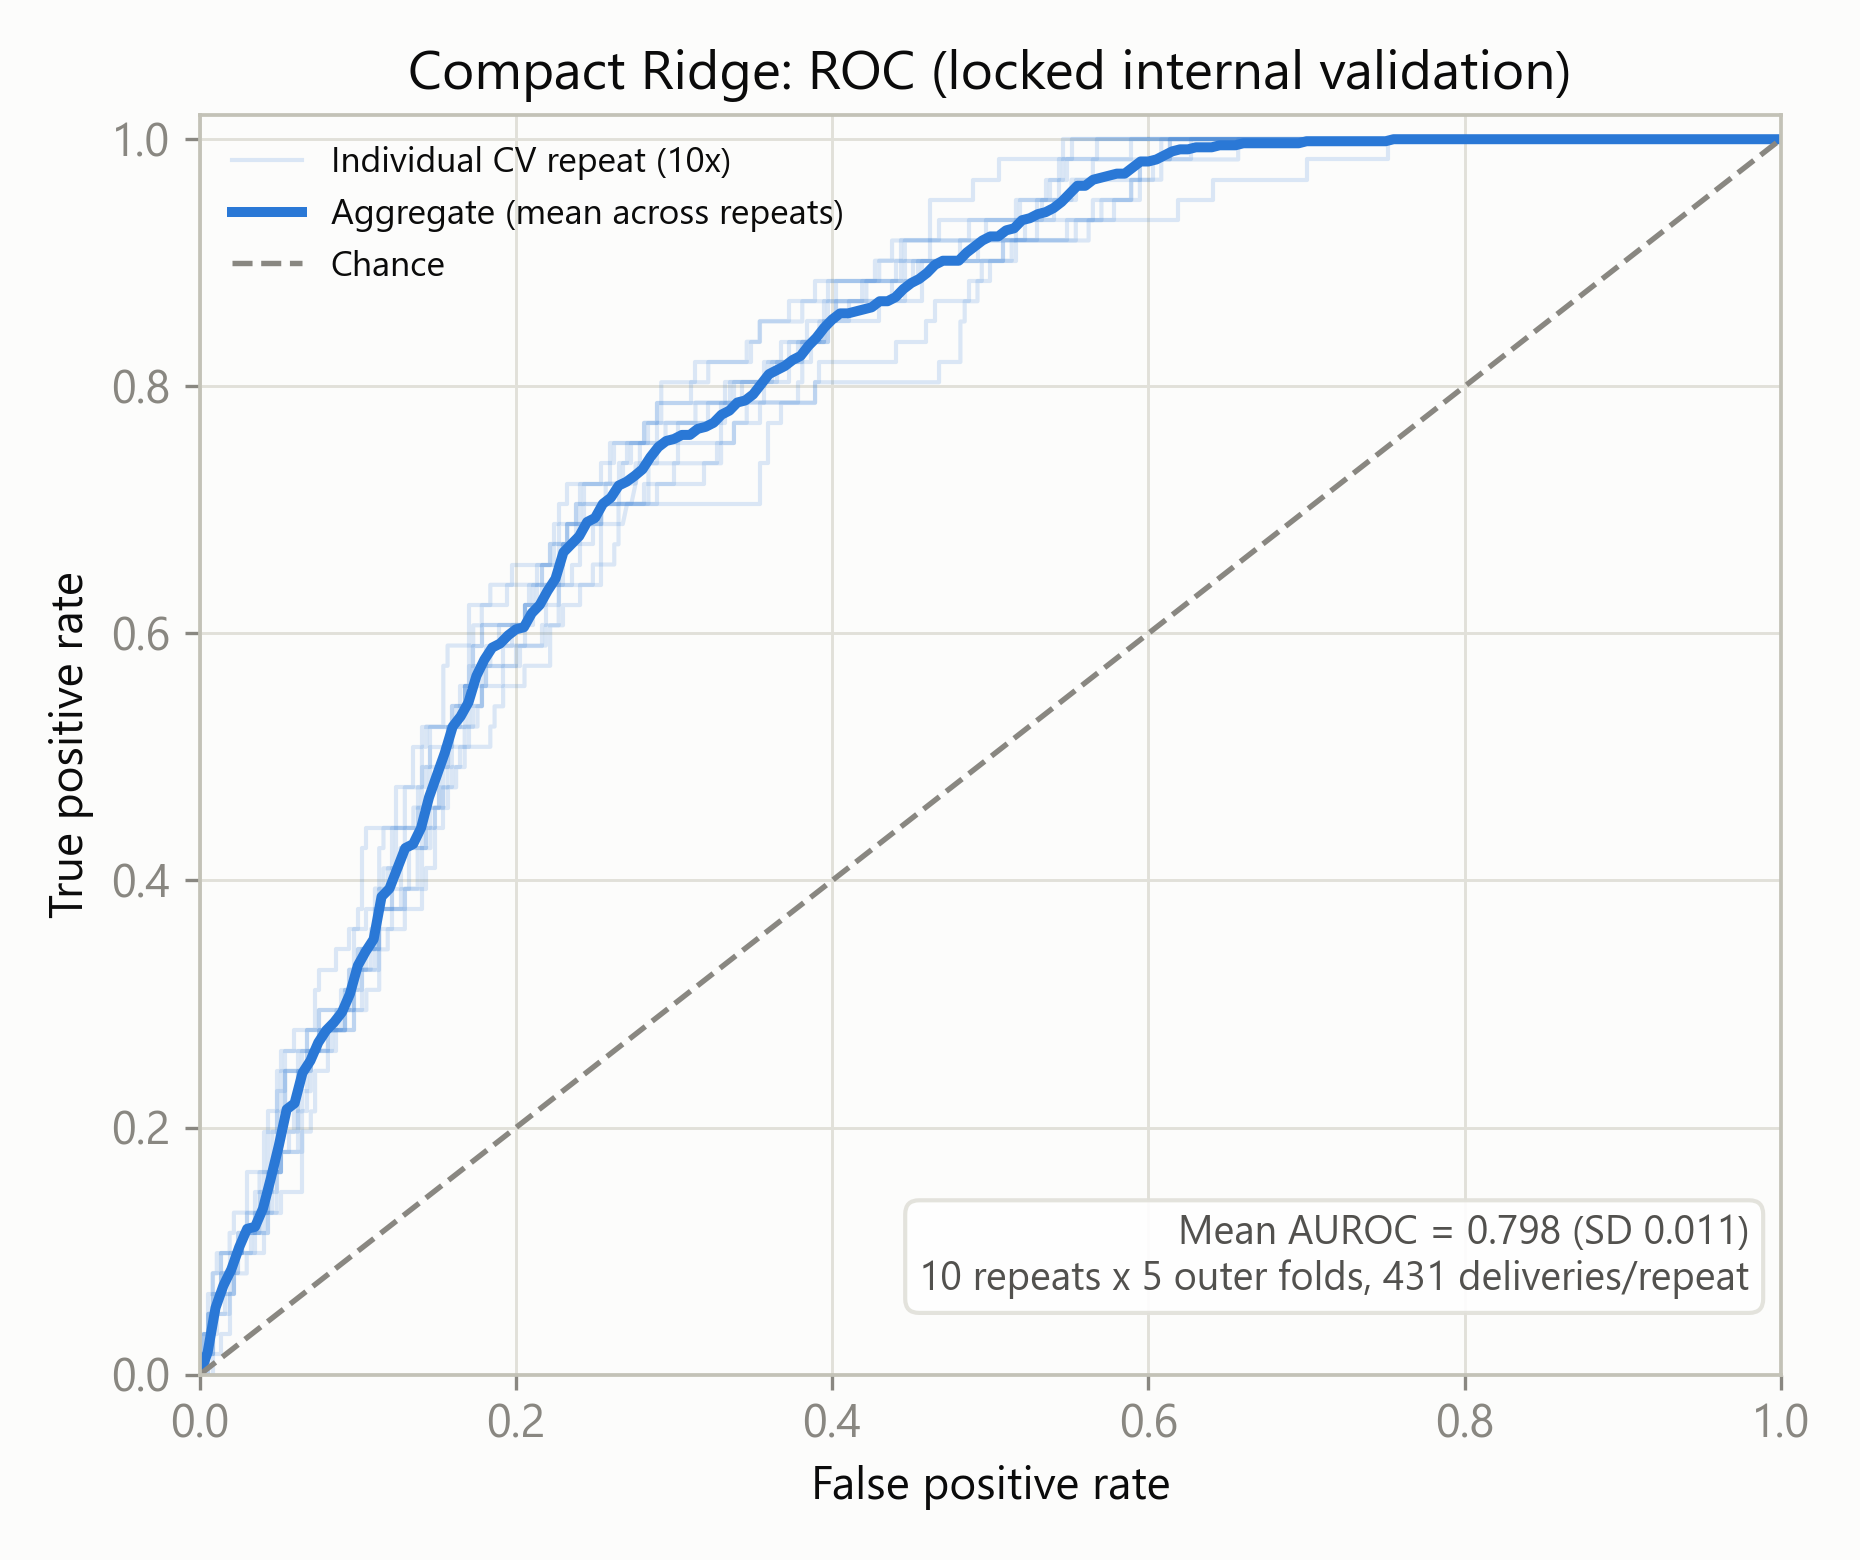

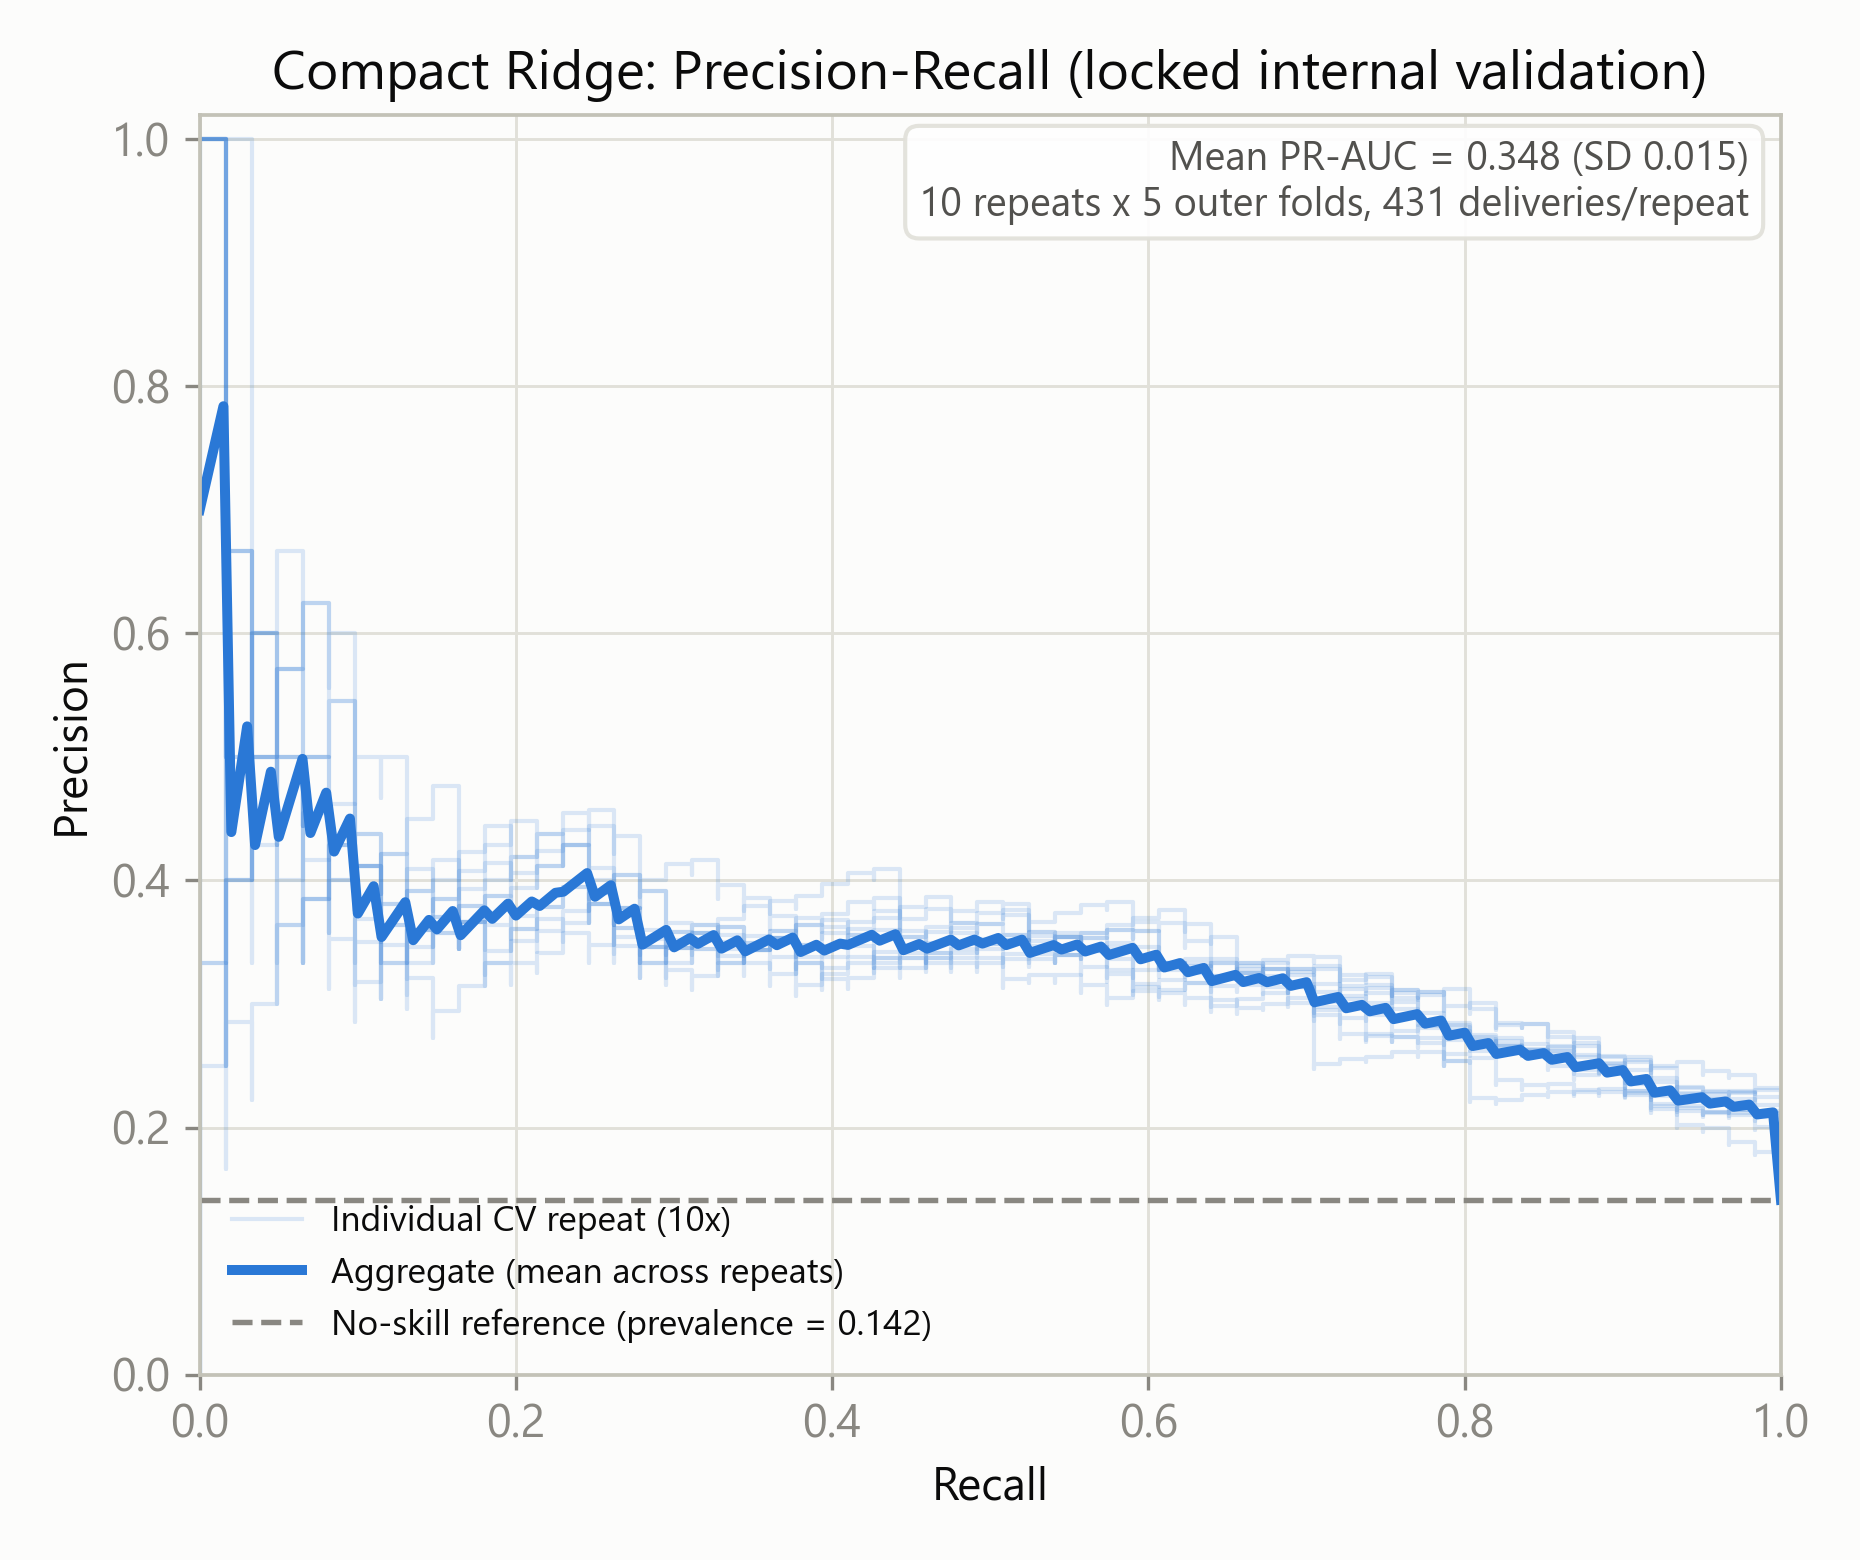

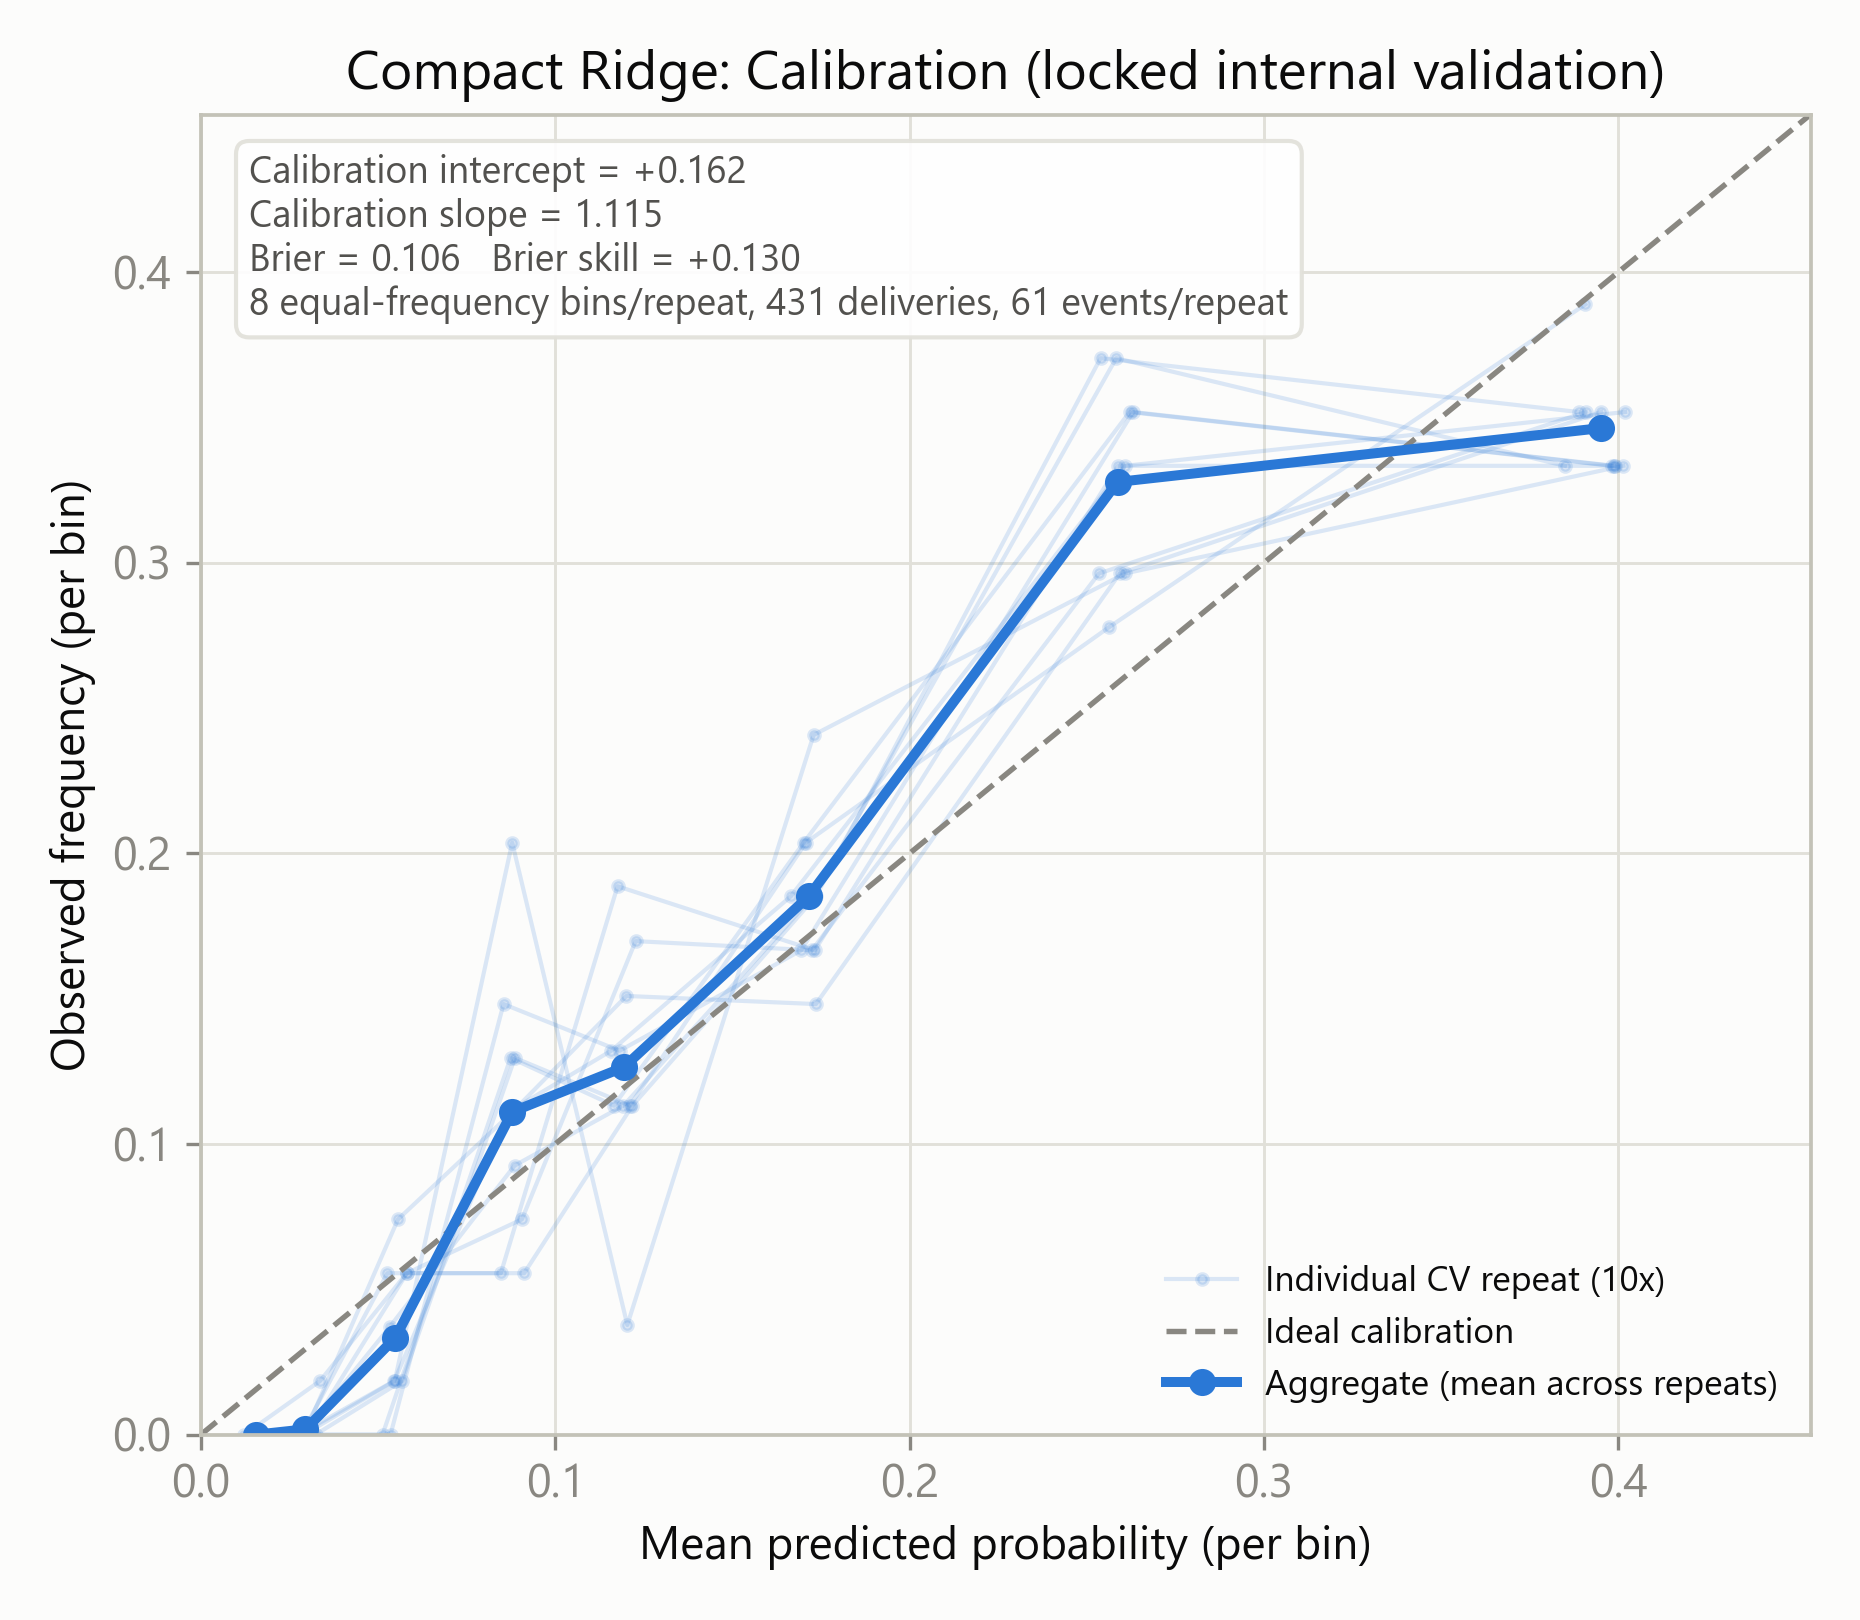

In [6]:
from IPython.display import Image, display

for fig_name in (
    "figure_compact_ridge_roc.png",
    "figure_compact_ridge_precision_recall.png",
    "figure_compact_ridge_calibration.png",
):
    display(Image(filename=str(FIGURES_DIR / fig_name)))

### Outer-fold coefficient stability (50 outer refits)

Sign consistency and coefficient spread for each frozen predictor across the
50 locked-validation outer folds --
`results/tables/reproducibility/coefficient_stability.csv`.
`BMI_before`'s sign consistency of 0.54 (vs. 1.00 for every other
continuous/binary predictor) is the basis for its "unstable" flag in D4.

In [7]:
coefficient_stability = pd.read_csv(REPORT_DIR / "coefficient_stability.csv")
coefficient_stability

,predictor,n_folds,median_coef,coef_iqr,sign_consistency
0,AGE,50,0.479021,0.085353,1.00
1,nulliparity,50,0.739058,0.142479,1.00
2,S_P_CS,50,0.343919,0.138650,1.00
3,BMI_before,50,-0.015245,0.098068,0.54
4,induction_any_bin,50,0.707509,0.091417,1.00


---
## D6 -- Limitations

* **Internal validation only.** Reported performance is repeated
  subject-grouped cross-validation performed *after* exploratory model
  development on this same development dataset -- not an independent test
  set, not external validation.
* **No hold-out.** The historical EDA D hold-out's row-level membership is
  unrecoverable after the 447 -> 431 cohort transition and is, by locked
  policy, never reconstructed or accessed. This model was never evaluated
  against any hold-out.
* **No endometriosis-specific predictor.** The completed exploratory
  endometriosis analyses (add-on, signal-recovery, feature-profiling,
  phenotype-aggregation, all on `exploratory/overnight-model-improvement`)
  found no stable incremental predictive value from any measured
  endometriosis phenotype/severity/surgical-history variable beyond the
  frozen obstetric core. That negative finding is retained as part of the
  scientific record, not overridden.
* **`BMI_before` coefficient instability.** Sign consistency 0.54 across the
  50 outer validation folds (vs. 1.00 for every other continuous/binary
  predictor) -- its full-refit coefficient direction should not be
  over-interpreted.
* **Ridge coefficients are not odds ratios.** D4's Ridge coefficient table
  reports penalized coefficients on the standardized/encoded scale; the
  separate adjusted-OR table is a secondary, prespecified descriptive
  association analysis, not a causal model.

In [8]:
reproducibility = final_refit_manifest.get("reproducibility", {})
print("Reproducibility manifest (from final_refit_manifest.json):")
for key, value in reproducibility.items():
    print(f"  {key}: {value}")

Reproducibility manifest (from final_refit_manifest.json):
  git_sha: 0cf9fd171847c82e66d7eb1fac1c5fc1011c4d14
  branch: final-model/compact-ridge-lock (isolated worktree, based on origin/main)
  eda_c_registry_sha256: 3ca23c0f9f11e340a962630c00ffa73447000e0a497975ddd79304861d1759e7
  eda_c_matrix_sha256: 12733c8548cdda2e3c19ae563b0750ba0f41173fc93eaed730f35f2c1f8a8c69


## D7 -- Provenance

Sources marked *(canonical only)* are not included in this submission
package; see the root `README.md` and `SUBMISSION_MANIFEST.md` for the
reproducibility tier this implies.

| | |
|---|---|
| Frozen architecture + validation + refit | `analysis/modeling/final_modeling/final_compact_ridge_lock.py` *(canonical only)* |
| Publication tables/figures generator | `analysis/reports/compact_ridge_final_outputs.py` *(canonical only)* |
| Scientific summary (current final architecture) | `documentation/COMPACT_RIDGE_FINAL_LOCK.md` (included in this submission) |
| Decision record | Decision 99, `docs/clinical_decisions/manual_decisions_log.md` *(canonical only)* |
| Repository index entry | `docs/finalization/FINAL_PROJECT_INDEX.md` §6b/§7b *(canonical only)* |
| Historical superseded winner (Stage 3 / LASSO) | `docs/finalization/FINAL_SCIENTIFIC_FREEZE.md` *(canonical only)* |

## D8 -- What this notebook does NOT do

* No new model selection, predictor search, or estimator comparison.
* No change to predictors, preprocessing, hyperparameters, or CV design.
* No new cross-validation, refit, or bootstrap.
* No hold-out access of any kind.
* No new scientific or clinical decision.

Every table and figure above is a read-only view of artifacts already
produced by the canonical scripts in D7.